In [4]:
import pymc as pm
import polars as pl
from pathlib import Path
import numpy as np
import arviz as az
from Fig4_VariabilityOfPol2WithCCP_PyMC_Bambi import (
    load_data,
    MODEL_FORMULA_PRED,
    PMCBModel,
    TARGET,
    DEFAULT_FIT_PARAMS,
    LINEAR_PREDICTORS,
    pymc_diagnostics,
    linear_predictors_from_beta,
)
from zfish.visualize.pyvista_utils import plot_points, get_points
import pyvista as pv
from zfish.plot.plot_commons import tpaths
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
from zfish.plot.plot_commons import BASE
from sklearn.metrics import r2_score

matplotlib.rcParams["axes.unicode_minus"] = False

In [5]:
def _run_asymtotic_and_linear_model(
    X: pl.DataFrame,
    y: pl.Series,
    asymt_predictor_name: str = "CCP",
    linear_predictor_names: tuple[str, ...] = (),
    model_name: str = "ccp-asympt",
    censored: tuple[float | None, float | None] | None = None,
    persist_path: Path | None = None,
    load_existing: bool = True,
    sample_params=None,
) -> PMCBModel:
    x__ = X[asymt_predictor_name]
    X__ = X[:, linear_predictor_names]

    if X__.is_empty():
        coords = None
    else:
        coords = {"linear_pred": X__.columns}

    if sample_params is None:
        sample_params = {}

    with pm.Model(coords=coords) as model:
        # Data
        x_ = pm.Data('x_', value=np.asarray(x__))
        X_ = pm.Data('X_', value=np.asarray(X__))
        y_ = pm.Data('y_', value=np.asarray(y))

        # x_ = np.asarray(x__)
        # X_ = np.asarray(X__)
        # y_ = np.asarray(y)


        # Prior Error
        sigma = pm.HalfCauchy("sigma", beta=2)

        # Prior Asymtotic Predictor
        asympt = pm.Normal("asymptote", 5, sigma=2)
        interc = pm.Normal("intercept", 0, sigma=1)
        rate = pm.Gamma("rate", alpha=10, beta=2.5)

        # Former Likelihood
        asympt_target = asympt - (asympt - interc) * pm.math.exp(-rate * x_)

        if coords is None:
            mu = asympt_target
        else:
            # Priors Linear Predictors
            beta = pm.Normal("beta", 0.0, 1.0, dims="linear_pred")
            mu = asympt_target + pm.math.dot(X_, beta)

        if censored is None:
            # Likelihood
            _ = pm.Normal(
                TARGET,
                mu=mu,
                sigma=sigma,
                observed=y_,
            )

        else:
            # Latent Likelihood
            target_latent = pm.Normal.dist(
                mu=mu,
                sigma=sigma,
            )

            _ = pm.Censored(
                TARGET,
                target_latent,
                lower=censored[0],
                upper=censored[1],
                observed=y_,
            )

        if persist_path is not None:
            persist_file = (
                persist_path
                / f"{model_name}{'' if censored is None else f'__c{censored}'}__idata.nc"
            )
        else:
            persist_file = None

        if persist_file is None:
            idata = pm.sample(
                **sample_params
            )

        else:
            if persist_file.exists() and load_existing:
                print(f"load existing idata: {persist_file}")
                idata = az.from_netcdf(persist_file)
            else:
                idata = pm.sample(
                    **sample_params
                )
                print(f"persisting idata: {persist_file}")
                idata.to_netcdf(persist_file)
        _ = pm.sample_posterior_predictive(idata, extend_inferencedata=True)

    return PMCBModel(
        name=model_name,
        model=model,
        idata=idata,
        x_asympt=x__,
        features_in=tuple([asymt_predictor_name] + list(linear_predictor_names)),
        persist_file=persist_file,
    )


In [6]:
sample_embryo = "F03_px-2043_py+0598"
cycle = 11
samples = 10_000
df, df_s = load_data()
model_name = 'zga_ccp-feats_ccp-asympt'
model_name_s5p = 's5p_zga_ccp-feats_ccp-asympt'


linear_predictors = MODEL_FORMULA_PRED[model_name]
linear_predictors_s5p = MODEL_FORMULA_PRED[model_name] + ('Pol2.S5P',)

nonlinear_predictor = "CCP"


print(f'target:     {TARGET}')
print(f'linear:     {', '.join(linear_predictors)}')
print(f'linear S5P: {', '.join(linear_predictors_s5p)}')
print(f'non-linear: {nonlinear_predictor}')

target:     Pol2.S2P
linear:     Pou5, Nanog, H3K27Ac, H2B, PCNA, DAPI, n_Volume, n.cy_VolumeRatio, n_Roundness, n_Flatness
linear S5P: Pou5, Nanog, H3K27Ac, H2B, PCNA, DAPI, n_Volume, n.cy_VolumeRatio, n_Roundness, n_Flatness, Pol2.S5P
non-linear: CCP


In [8]:
df_samp = (
    df_s.filter(pl.col("cycle") == cycle)
    .filter(pl.col("roi") != sample_embryo) # exclude the sample embryo
    .sample(samples, seed=42)
)

X = df_samp.select(linear_predictors_s5p + (nonlinear_predictor,))

y = df_samp[TARGET]

<Axes: ylabel='Count'>

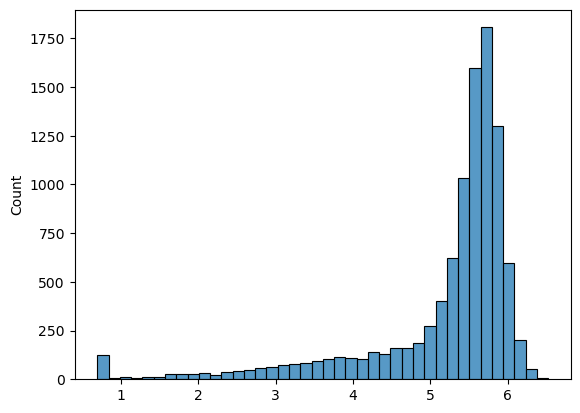

In [13]:
sns.histplot(y, bins=40)

In [ ]:
df_samp = (
    df_s.filter(pl.col("cycle") == cycle)
    .filter(pl.col("roi") != sample_embryo) # exclude the sample embryo
    .sample(samples, seed=42)
)

X = df_samp.select(linear_predictors_s5p + (nonlinear_predictor,))

y = df_samp[TARGET]

mdl = _run_asymtotic_and_linear_model(
    X,
    y,
    asymt_predictor_name=nonlinear_predictor,
    linear_predictor_names=linear_predictors,
    model_name=model_name,
)

mdl_s5p = _run_asymtotic_and_linear_model(
    X,
    y,
    asymt_predictor_name=nonlinear_predictor,
    linear_predictor_names=linear_predictors_s5p,
    model_name=model_name_s5p,
)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, asymptote, intercept, rate, beta]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 82 seconds.
Sampling: [Pol2.S2P]


Output()

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, asymptote, intercept, rate, beta]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 97 seconds.
Sampling: [Pol2.S2P]


Output()

Items starting with ~: ['^mu$', 'Intercept', '^.*_log__$'] have not been found and will be ignored


                         mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  \
asymptote               5.242  0.006   5.230    5.253      0.000    0.000   
beta[Pou5]              0.511  0.007   0.498    0.525      0.000    0.000   
beta[Nanog]             0.209  0.008   0.193    0.224      0.000    0.000   
beta[H3K27Ac]           0.084  0.007   0.070    0.098      0.000    0.000   
beta[H2B]               0.008  0.006  -0.003    0.018      0.000    0.000   
beta[PCNA]             -0.199  0.010  -0.218   -0.182      0.000    0.000   
beta[DAPI]              0.014  0.005   0.005    0.022      0.000    0.000   
beta[n_Volume]         -0.061  0.006  -0.073   -0.049      0.000    0.000   
beta[n.cy_VolumeRatio]  0.070  0.005   0.061    0.078      0.000    0.000   
beta[n_Roundness]       0.006  0.006  -0.004    0.017      0.000    0.000   
beta[n_Flatness]       -0.090  0.008  -0.107   -0.075      0.000    0.000   
intercept               2.105  0.069   1.973    2.237      0.001    0.001   

Items starting with ~: ['^mu$', 'Intercept', '^.*_log__$'] have not been found and will be ignored
Items starting with ~: ['^mu$', 'Intercept', '^.*_log__$'] have not been found and will be ignored


                         mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  \
asymptote               5.114  0.006   5.104    5.125      0.000    0.000   
beta[Pou5]              0.382  0.006   0.370    0.393      0.000    0.000   
beta[Nanog]             0.029  0.008   0.016    0.044      0.000    0.000   
beta[H3K27Ac]           0.045  0.006   0.032    0.056      0.000    0.000   
beta[H2B]              -0.012  0.005  -0.021   -0.004      0.000    0.000   
beta[PCNA]             -0.235  0.007  -0.248   -0.220      0.000    0.000   
beta[DAPI]             -0.002  0.004  -0.009    0.006      0.000    0.000   
beta[n_Volume]         -0.052  0.005  -0.062   -0.043      0.000    0.000   
beta[n.cy_VolumeRatio]  0.040  0.004   0.033    0.047      0.000    0.000   
beta[n_Roundness]      -0.010  0.005  -0.019   -0.002      0.000    0.000   
beta[n_Flatness]       -0.038  0.007  -0.051   -0.026      0.000    0.000   
beta[Pol2.S5P]          0.654  0.009   0.637    0.672      0.000    0.000   

Items starting with ~: ['^mu$', 'Intercept', '^.*_log__$'] have not been found and will be ignored


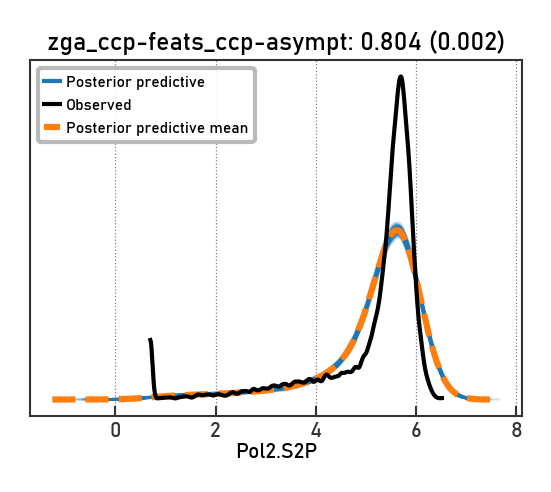

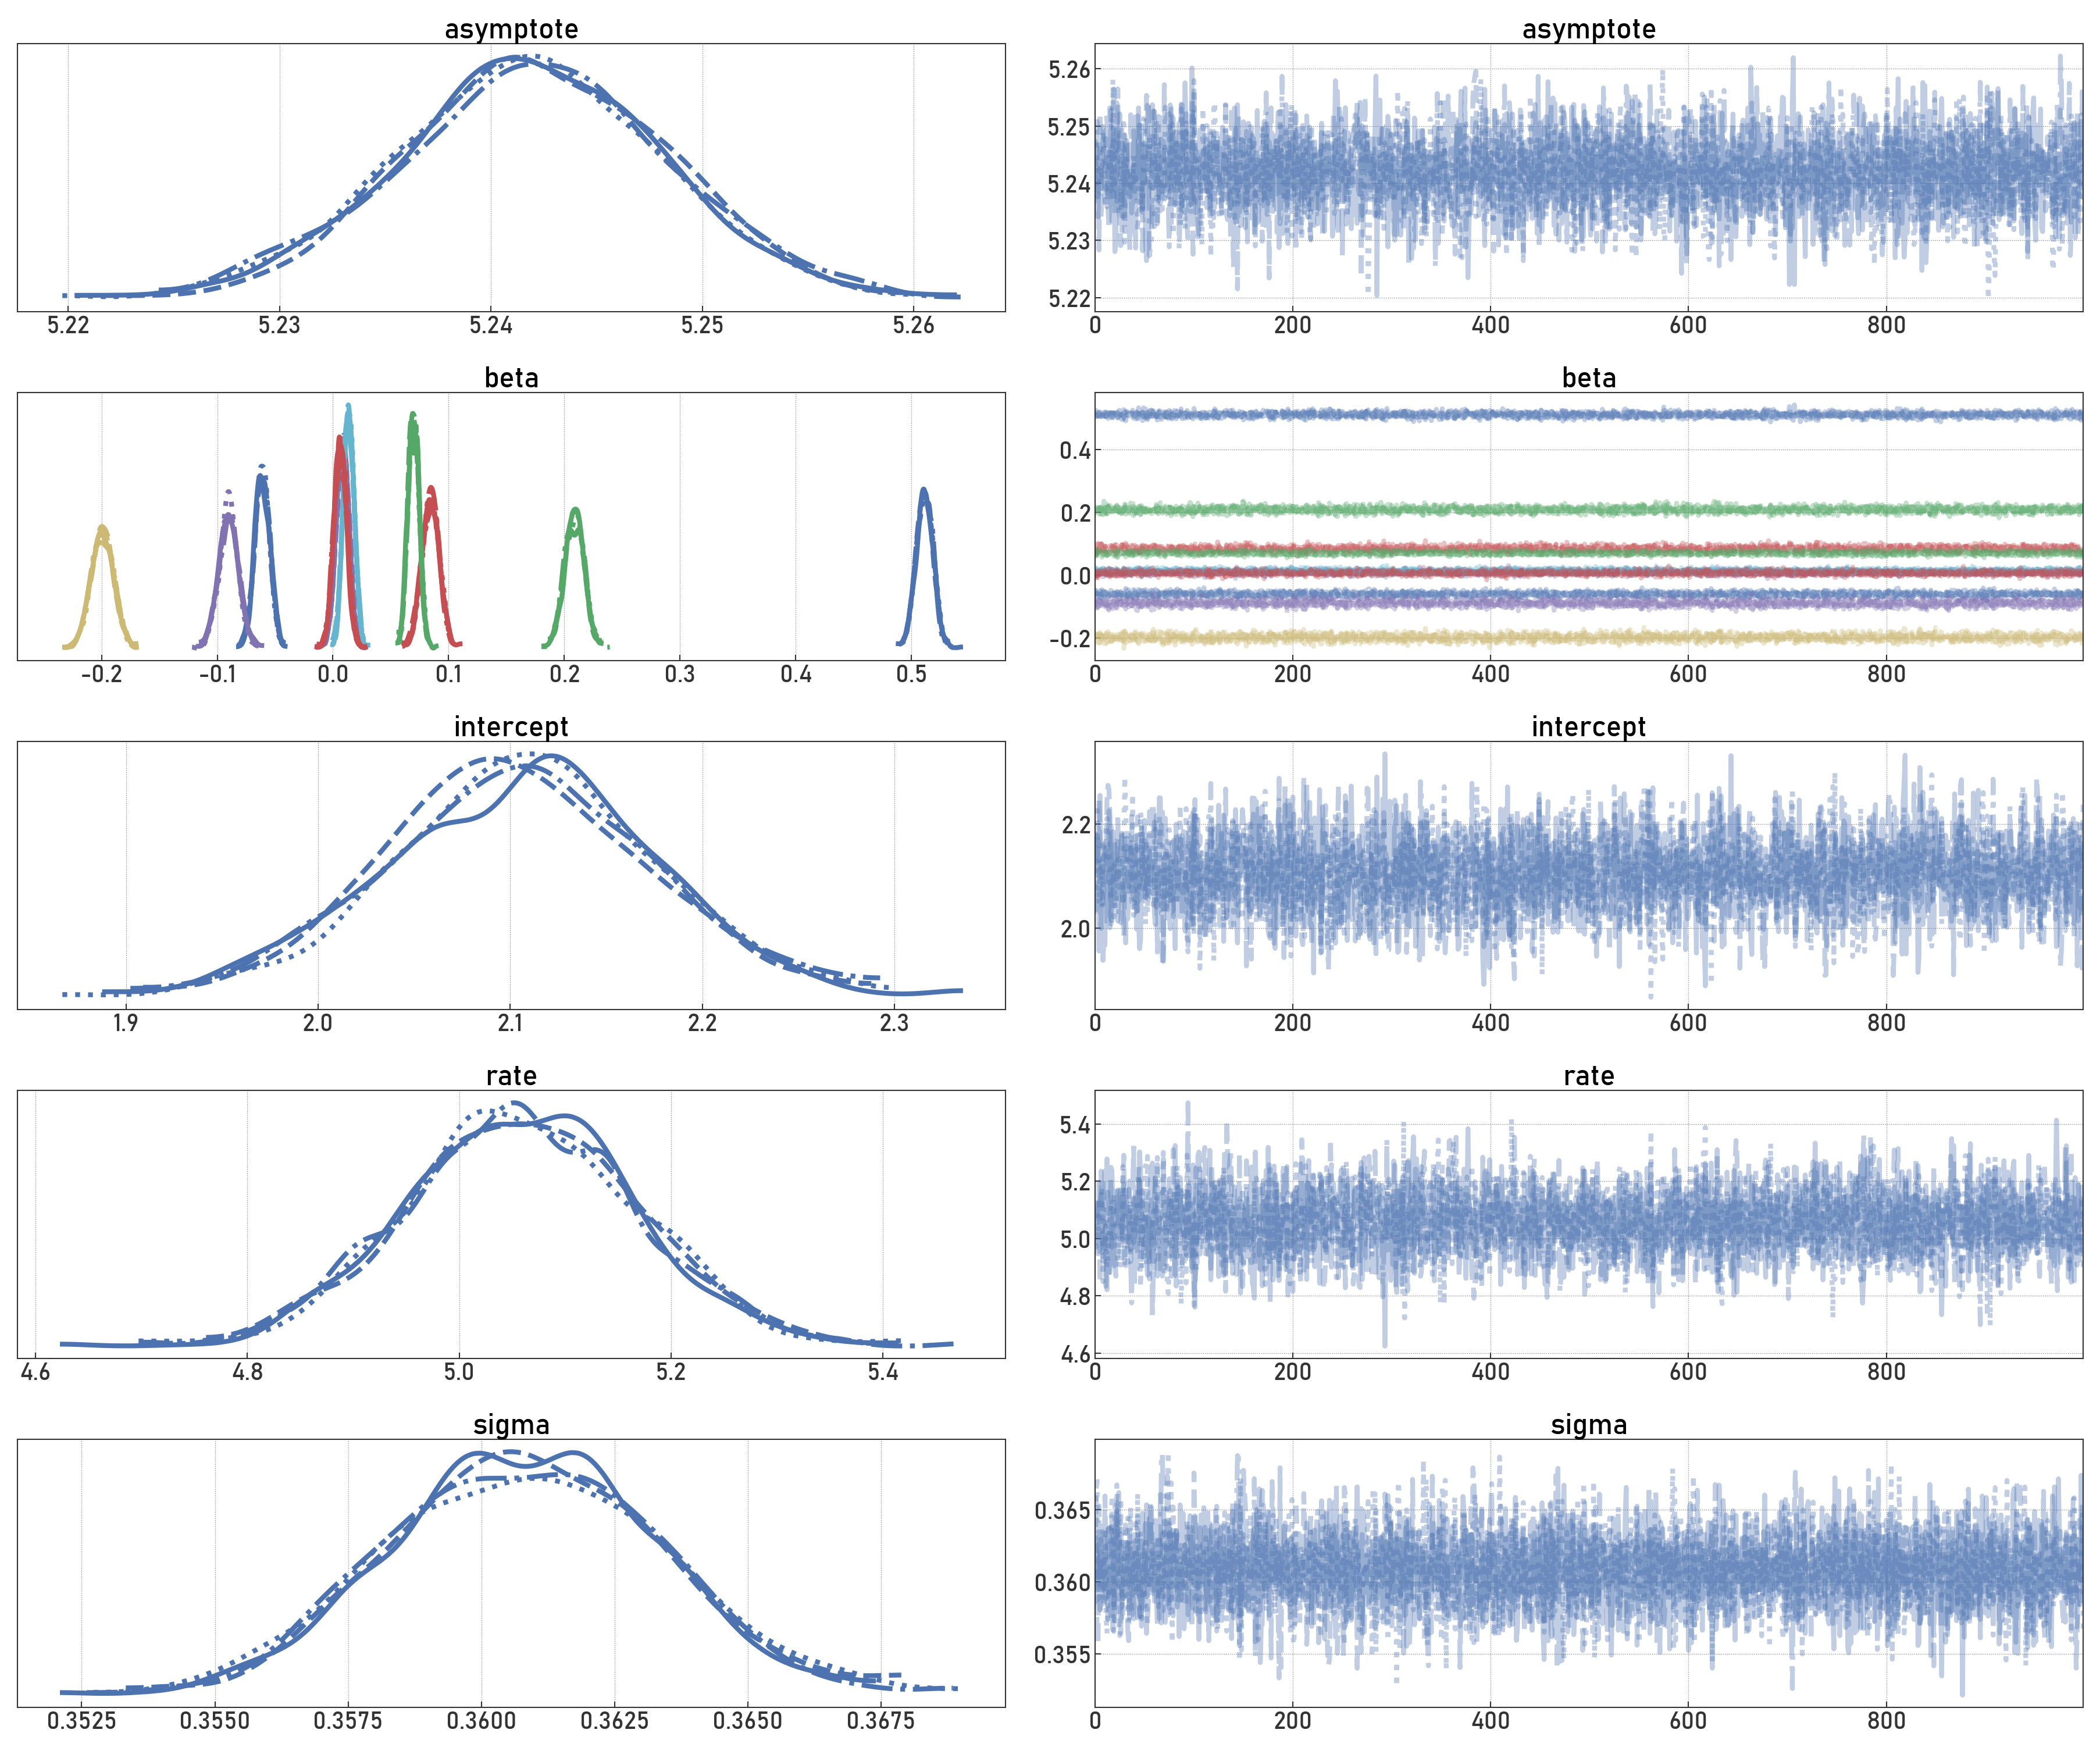

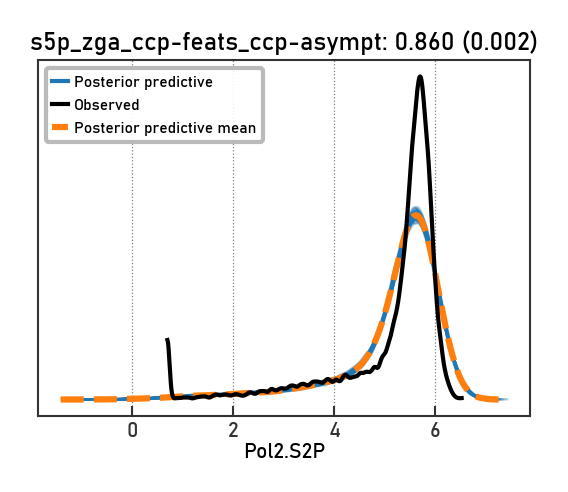

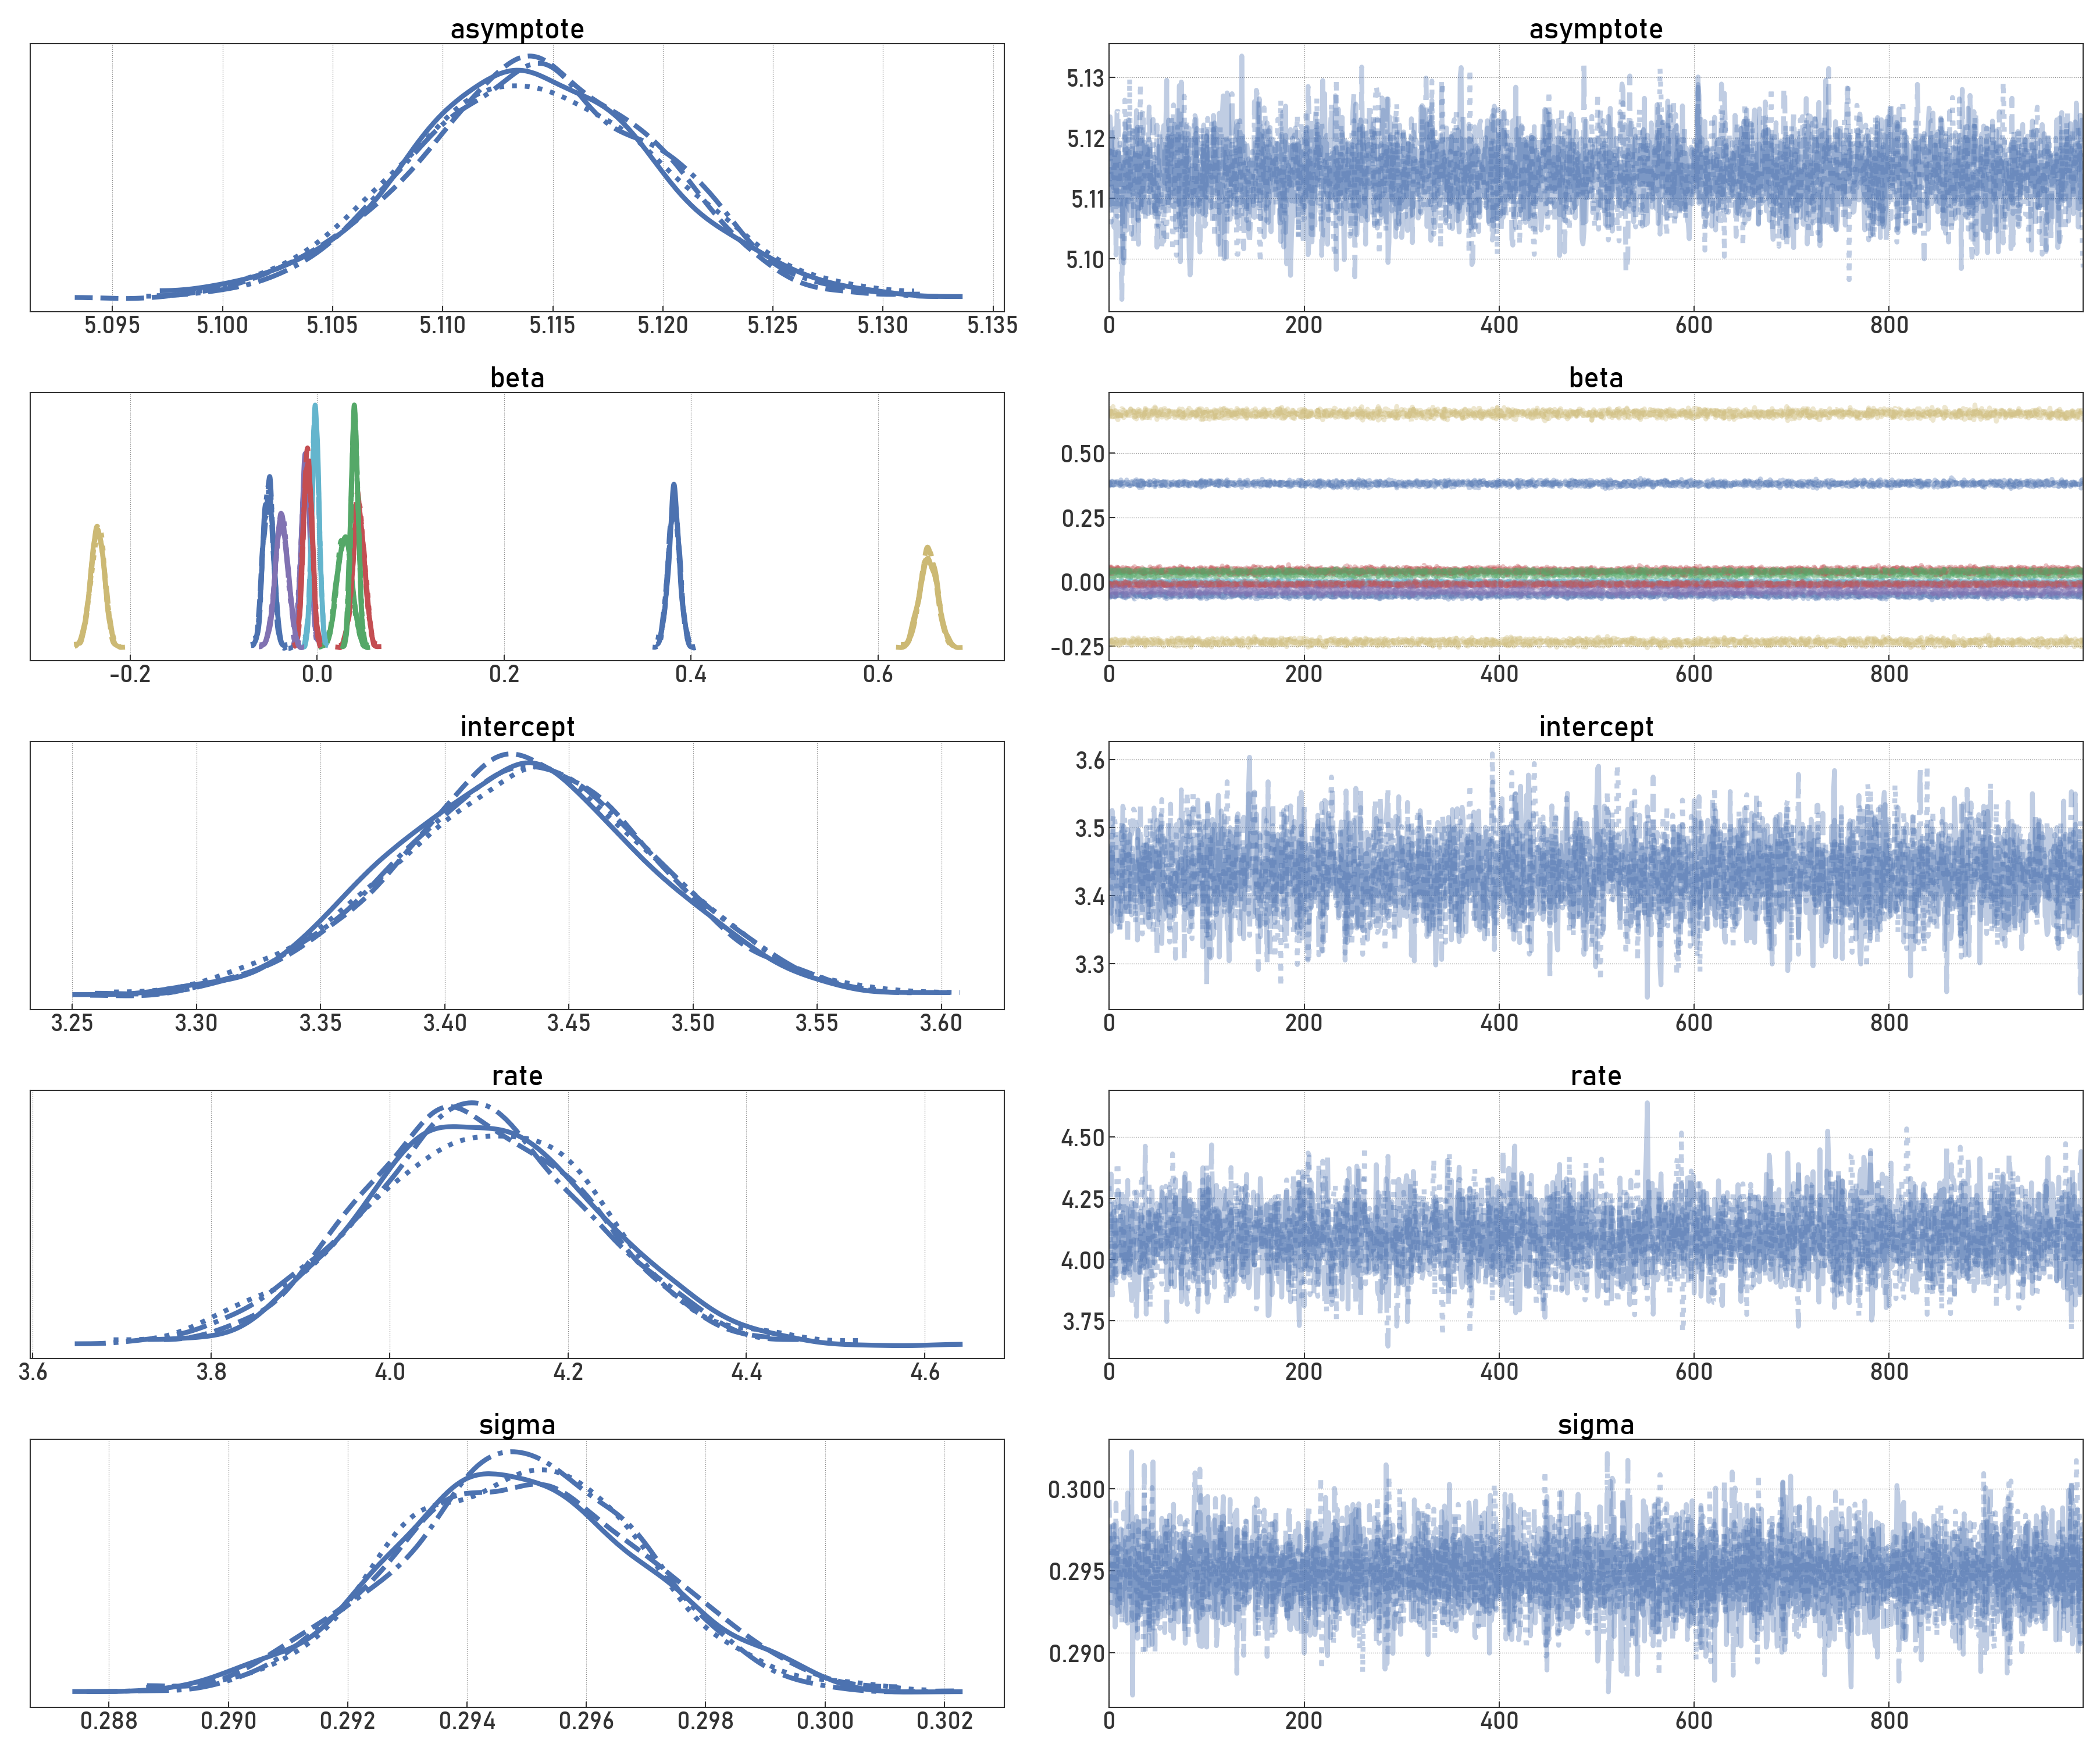

In [181]:
with plt.style.context(BASE):
    pymc_diagnostics(mdl)
    pymc_diagnostics(mdl_s5p)

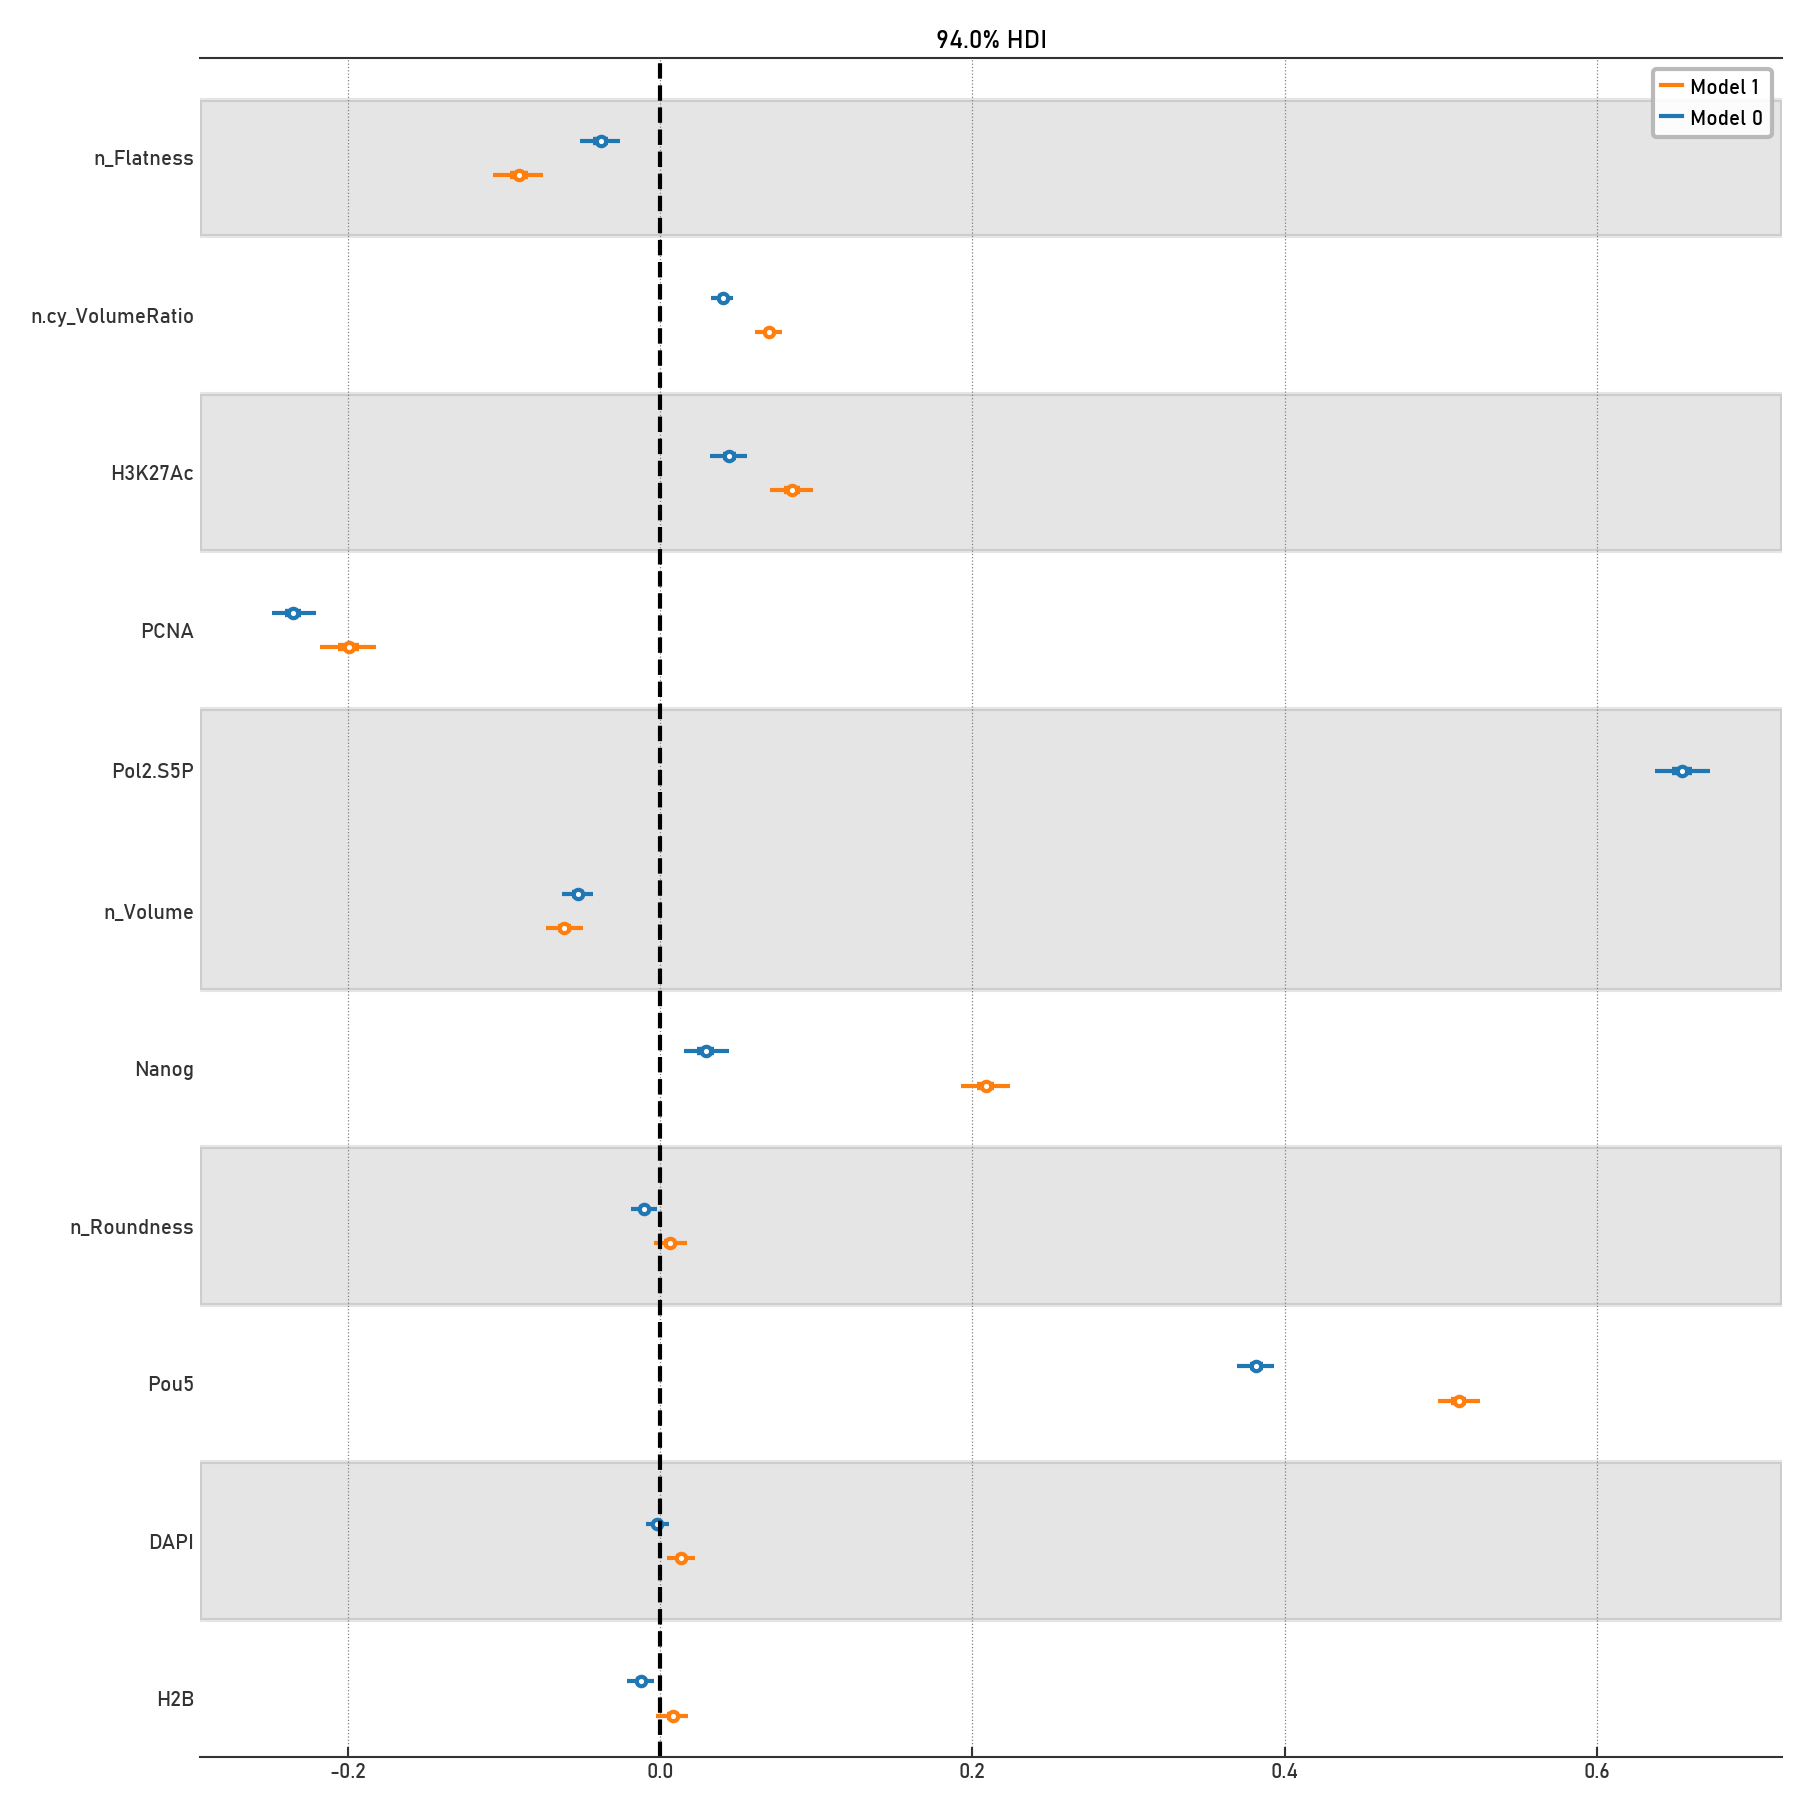

In [182]:
with plt.style.context(BASE):
    ax = az.plot_forest([linear_predictors_from_beta(mdl_s5p.idata, linear_predictors=linear_predictors_s5p), linear_predictors_from_beta(mdl.idata, linear_predictors=linear_predictors_s5p)], combined=True, figsize=(6, 6))
    ax[0].axvline(0, color="black", linestyle="--")

In [42]:
df_emb = df_s.filter(pl.col("roi") == sample_embryo)

X_emb = df_emb.select(linear_predictors_s5p + (nonlinear_predictor,))
y_emb = df_emb[TARGET]

with mdl.model:
    pm.set_data({"x_": np.asarray(X_emb[nonlinear_predictor]), "X_": np.asarray(X_emb[linear_predictors]), "y_": np.asarray(y_emb)})
    ppc = pm.sample_posterior_predictive(mdl.idata, var_names=[TARGET])

with mdl_s5p.model:
    pm.set_data({"x_": np.asarray(X_emb[nonlinear_predictor]), "X_": np.asarray(X_emb[linear_predictors_s5p]), "y_": np.asarray(y_emb)})
    ppc_s5p = pm.sample_posterior_predictive(mdl_s5p.idata, var_names=[TARGET])

Sampling: [Pol2.S2P]


Output()

Sampling: [Pol2.S2P]


Output()

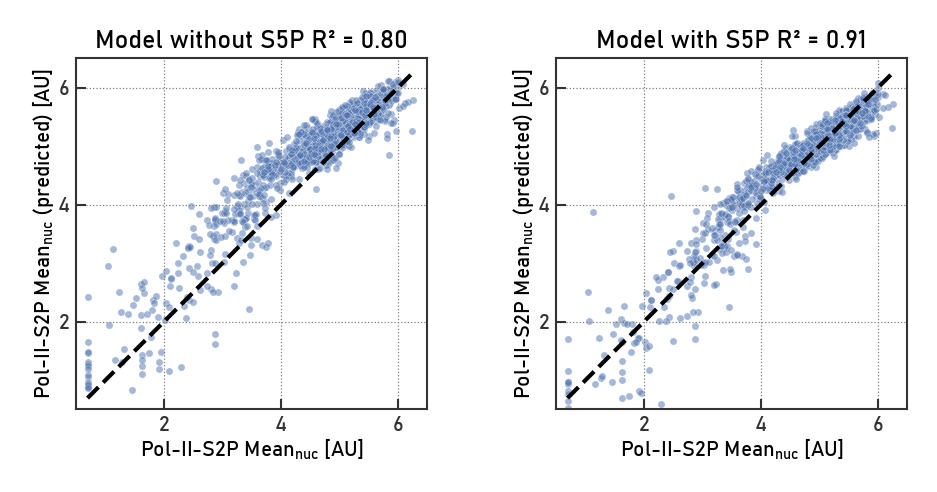

In [185]:
y_true = ppc.observed_data[TARGET]
y_pred = ppc.posterior_predictive[TARGET].mean(dim=("chain", "draw"))

y_pred_s5p = ppc_s5p.posterior_predictive[TARGET].mean(dim=("chain", "draw"))


xy_equal = np.linspace(y_true.min().item(), y_true.max().item(), 2)

with plt.style.context(BASE):
    fig, axs = plt.subplots(ncols=2, figsize=(3.2, 1.6))
    for i, (y_pred_, ax) in enumerate(zip((y_pred, y_pred_s5p), axs)):
        plt.sca(ax)
        sns.scatterplot(x=y_true, y=y_pred_, alpha=0.5, s=3)
        ax.set_xlabel("Pol-II-S2P $\\mathdefault{Mean_{nuc}}$ [AU]")
        ax.set_ylabel("Pol-II-S2P $\\mathdefault{Mean_{nuc}}$ (predicted) [AU]")

        # az.plot_hdi(y_true, hdi_data=az.hdi(ppc.posterior_predictive))
        # ax.vlines(
        #     y_true,
        #     *az.hdi(ppc.posterior_predictive[TARGET])[TARGET].transpose("hdi", ...),
        #     alpha=0.7,
        #     lw=0.3,
        #     color="black",
        # )
        plt.plot(xy_equal, xy_equal, color="black", linestyle="--")

        name = f"Model {'without' if i==0 else 'with'} S5P"
        ax.set_title(f"{name} R² = {r2_score(y_true, y_pred_):.2f}")

    for ax in axs.flatten():
        ax.set_aspect("equal")
        ax.set_ylim(0.5, 6.5)
        ax.set_xlim(0.5, 6.5)
        ax.set_xticks([2, 4, 6])

fig.savefig(tpaths.transcription / 'single_embryo_scatter_r2.png')

In [186]:
from zfish.visualize.napari_utils import napari_centroids
from zfish.multi_table.tables_io import scan_features, scan_resources

r = scan_resources().collect()

df_emb_full = (
    r.label_objects.filter(pl.col("roi") == sample_embryo)
    .filter(pl.col("o") == "nucleiRaw3")
    .join(
        df_emb.with_columns(
            pl.Series(f"{TARGET}_pred", y_pred.values),
            pl.Series(f"{TARGET}_s5p_pred", y_pred_s5p.values),
        ),
        on=["roi", "label"],
        how="left",
    )
)
df_emb_full

m,o,roi,label,m.iz.lower,m.iz.upper,m.iy.lower,m.iy.upper,m.ix.lower,m.ix.upper,centroid.z,centroid.y,centroid.x,o_right,Pol2.S2P,Pol2.S5P,PCNA,DAPI,n_Volume,n.cy_VolumeRatio,n_Roundness,n_Flatness,Pou5,Nanog,H3K27Ac,H2B,CCP,bCat,Noise,id_emb,cycle,cycle_p,ccp_class,celltype,Pol2.S2P_pred,Pol2.S2P_s5p_pred
u8,cat,cat,u32,i32,i32,i32,i32,i32,i32,f64,f64,f64,cat,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,i64,i64,str,str,f64,f64
1,"""nucleiRaw3""","""F03_px-2043_py+0598""",1,14,29,531,550,464,483,21.060951,350.959325,307.485392,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
1,"""nucleiRaw3""","""F03_px-2043_py+0598""",2,14,30,552,569,549,567,21.056398,363.939284,362.646158,"""cells""",5.590766,0.024206,-0.137949,0.124465,0.516589,-0.098137,0.930429,-0.486202,-0.031475,0.752968,0.043584,0.341679,2.092548,-0.382726,-0.51789,"""122""",12,12,"""S4""","""EVL""",5.428679,5.155264
1,"""nucleiRaw3""","""F03_px-2043_py+0598""",3,14,31,588,605,545,562,21.841504,387.468536,359.805557,"""cells""",5.556531,0.044744,-0.03876,-0.131606,0.697485,0.776492,0.887561,-0.656459,0.153704,0.691956,-0.472164,-0.021943,2.324763,-0.382726,0.129732,"""122""",12,12,"""S4""","""EVL""",5.50924,5.219427
1,"""nucleiRaw3""","""F03_px-2043_py+0598""",4,15,34,449,468,484,495,23.071286,297.273255,318.168195,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
1,"""nucleiRaw3""","""F03_px-2043_py+0598""",5,15,30,509,525,500,517,20.897354,335.521578,330.013184,"""cells""",5.364708,0.203176,0.289294,0.14303,-0.310917,0.658319,-0.330165,-0.560869,-0.1891,0.758276,0.069353,-0.511762,1.636389,-0.382726,0.27658,"""122""",12,12,"""S3""","""EVL""",5.357448,5.19935
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
1,"""nucleiRaw3""","""F03_px-2043_py+0598""",2862,257,271,566,578,877,889,264.495734,371.30529,574.135794,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
1,"""nucleiRaw3""","""F03_px-2043_py+0598""",2863,259,271,517,529,878,888,265.523965,339.996732,573.777941,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
1,"""nucleiRaw3""","""F03_px-2043_py+0598""",2864,260,271,203,216,646,659,266.078859,135.591527,423.788003,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null


In [187]:
import napari
import polars.selectors as cs
import cmap


viewer = napari.Viewer()
viewer.add_points(
    **napari_centroids(
        df_emb_full.filter(pl.col(TARGET).is_null()).with_columns(
            pl.col(TARGET).fill_null(-1)
        ),
        # features=cs.by_name("Pol2.S2P"),
        size=3,
        face_color="gray",
        # face_contrast_limits=(0, 6),
        # face_colormap=cmap.Colormap('viridis', under='#606060', over='red').to_mpl(),
    )
)
viewer.add_points(
    **napari_centroids(
        df_emb_full.filter(pl.col(TARGET).is_not_null()).with_columns(
            pl.col(TARGET).fill_null(-1)
        ),
        features=cs.by_name("Pol2.S2P"),
        face_contrast_limits=(0, 6.5),
        face_colormap=cmap.Colormap("viridis", under="#606060", over="red").to_mpl(),
        edge_color="#000000",
    )
)
viewer.add_points(
    **napari_centroids(
        df_emb_full.filter(pl.col(TARGET).is_not_null()).with_columns(
            pl.col(TARGET).fill_null(-1)
        ),
        features=cs.by_name("Pol2.S2P_pred"),
        face_contrast_limits=(0, 6.5),
        face_colormap=cmap.Colormap("viridis", under="#606060", over="red").to_mpl(),
        edge_color="#000000",
    )
)
viewer.add_points(
    **napari_centroids(
        df_emb_full.filter(pl.col(TARGET).is_not_null()).with_columns(
            pl.col(TARGET).fill_null(-1)
        ),
        features=cs.by_name("Pol2.S2P_s5p_pred"),
        face_contrast_limits=(0, 6.5),
        face_colormap=cmap.Colormap("viridis", under="#606060", over="red").to_mpl(),
        edge_color="#000000",

    )
)

Argument 'edge_width' is deprecated, please use 'border_width' instead. The argument 'edge_width' was deprecated in 0.5.0 and it will be removed in 0.6.0.
Argument 'edge_color' is deprecated, please use 'border_color' instead. The argument 'edge_color' was deprecated in 0.5.0 and it will be removed in 0.6.0.
Argument 'edge_width' is deprecated, please use 'border_width' instead. The argument 'edge_width' was deprecated in 0.5.0 and it will be removed in 0.6.0.
Argument 'edge_color' is deprecated, please use 'border_color' instead. The argument 'edge_color' was deprecated in 0.5.0 and it will be removed in 0.6.0.
Argument 'edge_width' is deprecated, please use 'border_width' instead. The argument 'edge_width' was deprecated in 0.5.0 and it will be removed in 0.6.0.
Argument 'edge_color' is deprecated, please use 'border_color' instead. The argument 'edge_color' was deprecated in 0.5.0 and it will be removed in 0.6.0.
Argument 'edge_width' is deprecated, please use 'border_width' instead

<Points layer 'Points [3]' at 0x258c5a5eae0>

In [215]:
conditions = [TARGET, f"{TARGET}_pred", f"{TARGET}_s5p_pred"]

df_s2p = pl.concat(
    [
        df_emb_full.select(pl.col(condition).alias(TARGET)).with_columns(pl.lit(condition).alias("condition"))
        for condition in conditions
    ]
).filter(pl.col(TARGET).is_not_null())

(shared_hue_norm,) = (
    df_s2p.filter(pl.col(TARGET).is_not_null())
    .select(
        pl.col(TARGET).quantile(0.01).alias("lower"),
        pl.col(TARGET).quantile(0.99).alias("upper"),
    )
    .rows()
)

hue_norms = (
    df_s2p.group_by("condition", maintain_order=True)
    .agg(
        pl.col(TARGET).quantile(0.02).alias("lower"),
        pl.col(TARGET).quantile(0.98).alias("upper"),
    )
    .select("lower", "upper")
    .rows()
)



In [216]:
view_top = [
    (-624.1887564588251, 638.2922113408245, 169.0606101813167),
    (153.75861623642444, 367.7951700455927, 310.1667393924526),
    (-0.36175017851916225, -0.8803466706702958, 0.30680050159848227),
]


view_bottom = [
    (725.5785121937919, 940.6548224022536, 103.25448866429328),
    (163.61411795088694, 360.036282274658, 316.2329716083828),
    (-0.7388311084994212, 0.6504086835852089, -0.17634380462741636),
]

In [217]:


outlier_size = 5
cell_size = 20
outlier_color = "gray"
cell_colormap = "viridis"


po = pv.Plotter(shape=(1, len(conditions)), window_size=[4000, 1000], off_screen=True)
po.add_axes(xlabel='Z', ylabel='Y', zlabel='X')
po.enable_anti_aliasing(aa_type="msaa", multi_samples=64)
for i, condition in enumerate(conditions):
    po.subplot(0, i)
    plot_points(
        get_points(df_emb_full.filter(pl.col(TARGET).is_null())),
        size=outlier_size,
        color=outlier_color,
        po=po,
    )
    plot_points(
        get_points(
            df_emb_full.filter(pl.col(TARGET).is_not_null()),
            features=[TARGET, f"{TARGET}_pred", f"{TARGET}_s5p_pred"],
        ),
        size=cell_size,
        hue=condition,
        palette=cell_colormap,
        po=po,
        hue_norm=shared_hue_norm,
    )
po.link_views()
po.show(cpos=view_top, auto_close=False)
po.screenshot(tpaths.transcription / 'single_embryo_predictions_sidebyside_top_sharedcmap.png')

po.show(cpos=view_bottom, auto_close=False)
po.screenshot(tpaths.transcription / 'single_embryo_predictions_sidebyside_bottom_sharedcmap.png')
po.close()
# cpos = po.show(return_cpos=True, cpos=view_top)

In [218]:
from zfish.visualize.pyvista_utils import plot_points, get_points
import pyvista as pv

outlier_size = 5 * 2
cell_size = 20 * 2
outlier_color = "gray"
cell_colormap = "viridis"


po = pv.Plotter(window_size=[1333, 1000], off_screen=True)
po.add_axes(xlabel='Z', ylabel='Y', zlabel='X')
po.enable_anti_aliasing()

plot_points(
    get_points(df_emb_full.filter(pl.col(TARGET).is_null())),
    size=outlier_size,
    color=outlier_color,
    po=po,
)
plot_points(
    get_points(
        df_emb_full.filter(pl.col(TARGET).is_not_null()),
        features=[TARGET, f"{TARGET}_pred", f"{TARGET}_s5p_pred"],
    ),
    size=cell_size,
    hue=conditions[0],
    palette=cell_colormap,
    po=po,
    hue_norm=shared_hue_norm,
)
for i, condition in enumerate(conditions):
    print(condition)
    po.mesh.set_active_scalars(condition)
    po.show(cpos=view_top, auto_close=False)
    po.screenshot(tpaths.transcription / f'single_embryo_predictions_top__{condition}.png')
    po.show(cpos=view_bottom, auto_close=False)
    po.screenshot(tpaths.transcription / f'single_embryo_predictions_bottom__{condition}.png')


po.close()


Pol2.S2P
Pol2.S2P_pred
Pol2.S2P_s5p_pred


In [ ]:
tpaths.transcription / 'single_embryo_scatter_r2.png'

WindowsPath('C:/Users/hessm/Documents/Programming/Python/thesis/Figures/Results/Transcription/single_embryo_scatter_r2.png')